# Quickstart

This notebook shows the teleporting walkers sampler in action on a simple 2D
Gaussian target. This is designed to confirm the algorithm samples correctly
before looking at the more detailed benchmark notebooks (03-05). For an
explanation of how the algorithm works, see `docs/algorithm_design.md`.

In [1]:
!git clone https://github.com/thunderbolt190/teleport-mcmc.git
%cd teleport-mcmc
!pip install -e ".[dev]" -q

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from teleport.kernels.teleporting import teleporting_walkers_jax
from teleport.targets import log_prob_gaussian2d, GAUSSIAN2D_MEAN

Cloning into 'teleport-mcmc'...
remote: Enumerating objects: 757, done.
remote: Counting objects: 100% (196/196), done.
remote: Compressing objects: 100% (189/189), done.
remote: Total 757 (delta 112), reused 6 (delta 6), pack-reused 561 (from 1)
Receiving objects: 100% (757/757), 516.99 KiB | 2.58 MiB/s, done.
Resolving deltas: 100% (445/445), done.
/content/teleport-mcmc
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 21.2 MB/s eta 0:00:00
  Building editable for teleport-mcmc (pyproject.toml) .

In [2]:
# Run the teleporting walkers sampler on a 2D Gaussian target
key = jax.random.PRNGKey(0)
n_walkers = 20

init_walkers = jax.random.normal(key, shape=(n_walkers, 2))
final_walkers, chain, accepts, teleports = teleporting_walkers_jax(
    init_walkers, log_prob_gaussian2d, step_size=0.5, n_steps=2000, key=key
)

print("Acceptance rate:", float(jnp.mean(accepts)))
print("Teleport rate:", float(jnp.mean(teleports)))

Acceptance rate: 0.9350000619888306
Teleport rate: 0.9305000305175781


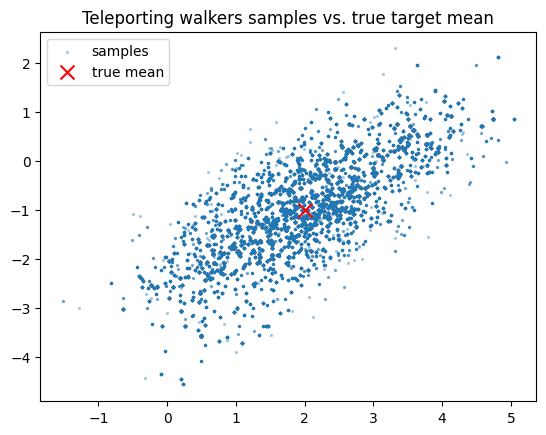

In [3]:
# Plot samples (after burn-in) against the true target mean
samples = chain[500:].reshape(-1, 2)

fig, ax = plt.subplots()
ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.3, label="samples")
ax.scatter(*GAUSSIAN2D_MEAN, color="red", marker="x", s=100, label="true mean")
ax.legend()
ax.set_title("Teleporting walkers samples vs. true target mean")
plt.show()

The sampled points should cluster around the true mean (red X). For IAT
comparisons against Goodman-Weare and a more detailed look at acceptance/
teleport probability trends, see `notebooks/03_iat_vs_doublewell.ipynb`,
`04_teleporting_vs_gw.ipynb`, and `05_accept_teleport_vs_n_doublewell.ipynb`.